# **ACF and PACF of ARMA(p,q) model**

In [ ]:
#base library
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# statstical model library
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.tsa.api as tsa

**Construction of sample ARMA(p,q) process.**
Use the function from statmodel library (statsmodels.tsa.arima_process.ArmaProcess).

$(1-\phi_1 B-\phi_2 B^2 - \cdots - \phi_p B^p) x_t = (1+ \theta_1 B +  \theta_2 B^2 + \cdots + \theta_q B^q) w_t$

The $\phi(B)$ and $\theta(B)$ are defined in AR and MA, respectively.

In [ ]:
# If we want to create (1- 0.75B +0.25B^2 )x_t = (1+0.65B+0.35B^2)w_t, it will be
# AR = np.array([1, -0.75, 0.25])
# MA = np.array([1,  0.65,  0.35])
AR = np.array([1, 0.8, 0.5])
MA = np.array([1, 0.9])
arma_process = tsa.ArmaProcess(AR, MA)

# Because we constuct this process with arbitrary parameter, let's check for stability and invertibility
print("Stable: ", arma_process.isstationary)
print("Invertible: ", arma_process.isinvertible)

# If you want to see the pole and zeros
#print("pole: ", arma_process.arroots)
#print("zero: ", arma_process.maroots)
dta_raw = arma_process.generate_sample(400) # 400 = the number of observations


Stable:  True
Invertible:  True


Add fake time index to make it more like time series model.



<Axes: >

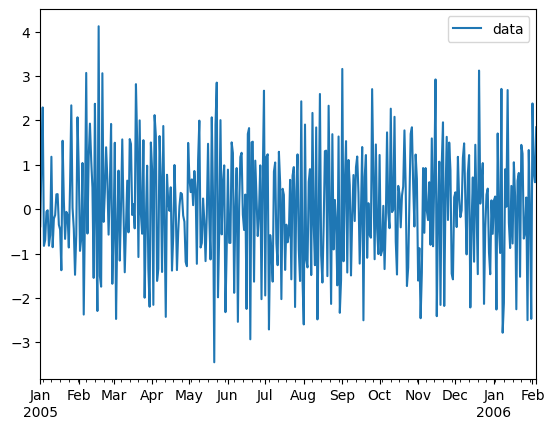

In [ ]:
n = len(dta_raw)
my_timeframe = pd.date_range(start='1/1/2005', periods=n, freq='D')
my_df = pd.DataFrame({
    'data' : dta_raw},
    index = my_timeframe
)
#display(my_df.head())
my_df.plot()

Plot ACF and PACF here.

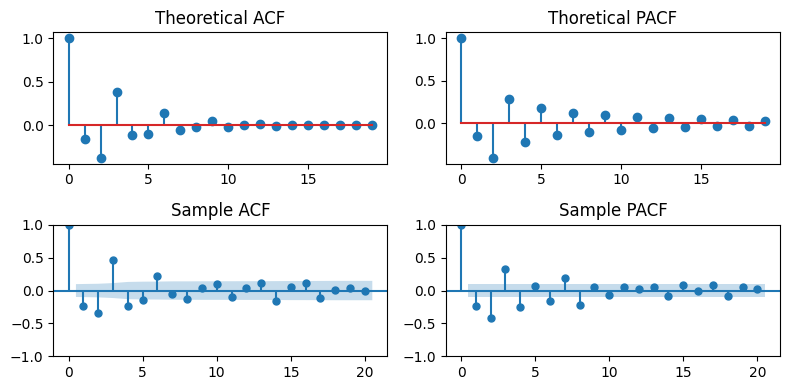

In [ ]:
fig,ax = plt.subplots(2,2,figsize=(8,4), tight_layout=True)
_ = sm.graphics.tsa.plot_acf(my_df.data, lags=20, title='Sample ACF', ax=ax[1,0])
_ = sm.graphics.tsa.plot_pacf(my_df.data, lags=20, title='Sample PACF', ax=ax[1,1])
x = np.arange(0,20,1)
ax[0,0].stem(x, arma_process.acf(20)); ax[0,0].title.set_text('Theoretical ACF')
ax[0,1].stem(x, arma_process.pacf(20)); ax[0,1].title.set_text('Thoretical PACF')


Put in some functions to make the example concise.

In [ ]:
def plotACF_PACF(arma_process, arma_sample, num_lag, title):
  x = np.arange(0,num_lag,1)
  fig,ax = plt.subplots(2,2,figsize=(8,4), tight_layout=True)
  _ = sm.graphics.tsa.plot_acf(arma_sample, lags=num_lag, title='Sample ACF', ax=ax[1,0])
  _ = sm.graphics.tsa.plot_pacf(arma_sample, lags=num_lag, title='Sample PACF', ax=ax[1,1])
  ax[0,0].stem(x, arma_process.acf(num_lag)); ax[0,0].title.set_text('Theoretical ACF')
  ax[0,1].stem(x, arma_process.pacf(num_lag)); ax[0,1].title.set_text('Thoretical PACF')
  fig.suptitle(title, fontsize=16)


# **EXAMPLE**
Comparison of white nose, MA, AR and ARMA process.

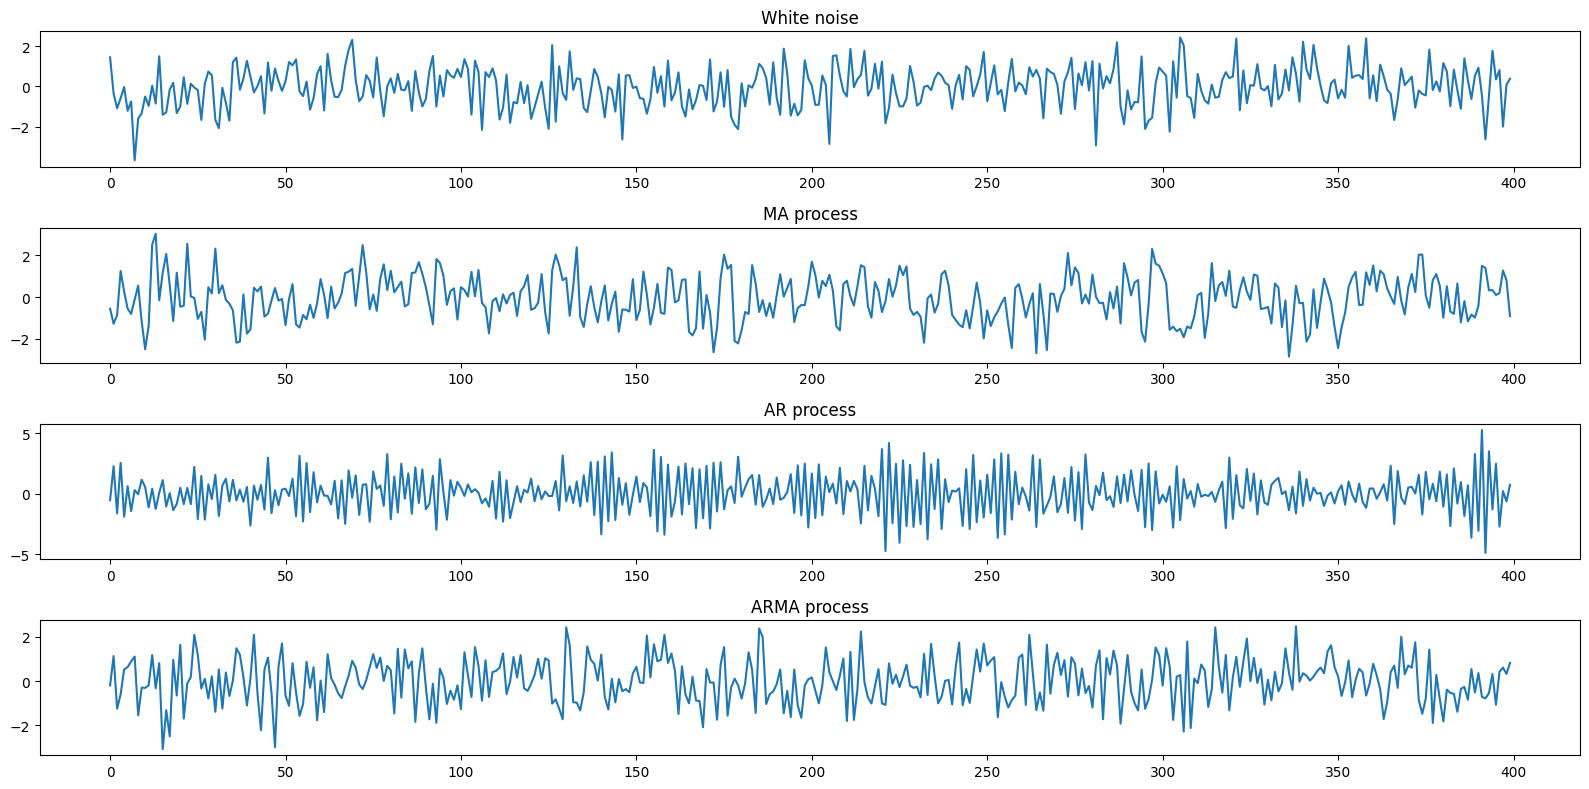

In [ ]:

num_sample = 400
white_noise_process = tsa.ArmaProcess([1], [1])
ma_process = tsa.ArmaProcess([1], [1, 0.4])
ar_process = tsa.ArmaProcess([1,0.8], [1])
arma_process = tsa.ArmaProcess([1,0.8], [1,0.8])

#generate sample
wn_data = white_noise_process.generate_sample(num_sample)
ma_data = ma_process.generate_sample(num_sample)
ar_data = ar_process.generate_sample(num_sample)
arma_data = arma_process.generate_sample(num_sample)

x = np.arange(0,num_sample, 1)
fig, ax = plt.subplots(4,1, figsize=(16,8), tight_layout=True)
ax[0].plot(x, wn_data); ax[0].title.set_text('White noise')
ax[1].plot(x, ma_data); ax[1].title.set_text('MA process')
ax[2].plot(x, ar_data); ax[2].title.set_text('AR process')
ax[3].plot(x, arma_data); ax[3].title.set_text('ARMA process')

ACF and PACF of MA, AR and ARMA process


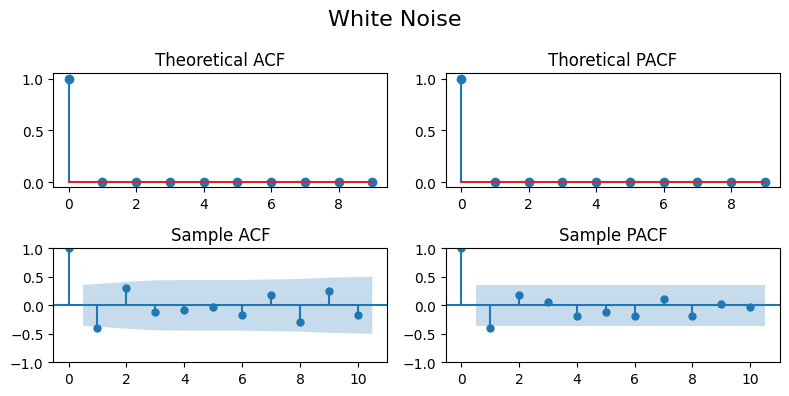

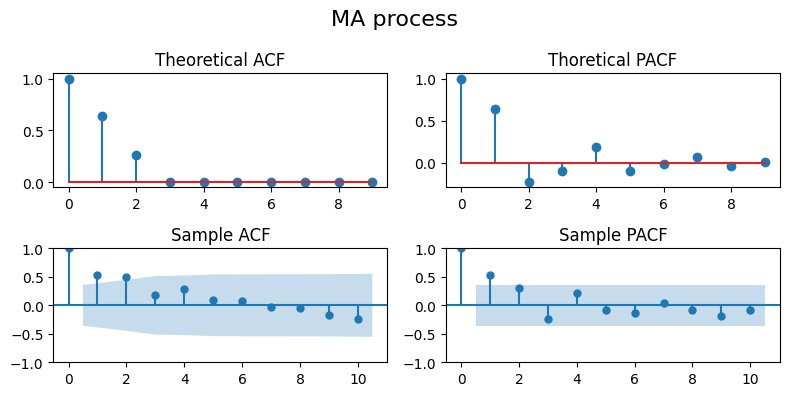

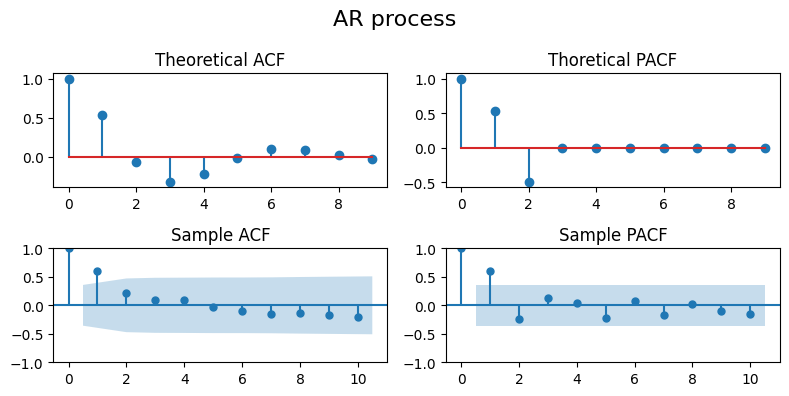

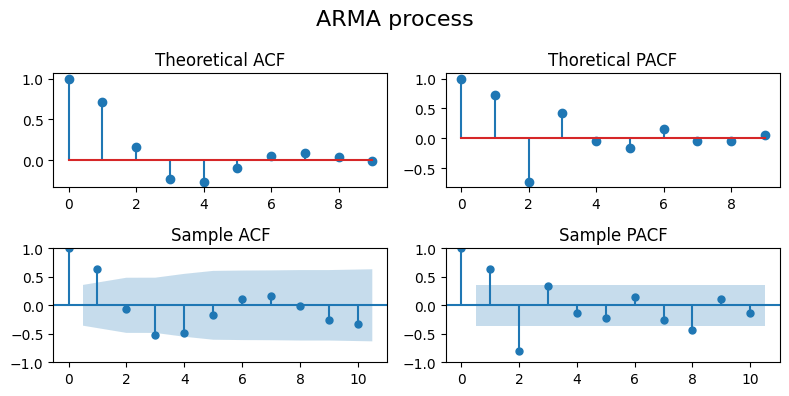

In [ ]:
num_sample = 30
wn_process = tsa.ArmaProcess([1], [1])
ma_process = tsa.ArmaProcess([1], [1, 0.8, 0.5])
ar_process = tsa.ArmaProcess([1,-0.8, 0.5], [1])
arma_process = tsa.ArmaProcess([1,-0.8, 0.5], [1, 0.8, 0.5])

#generate sample
wn_data = wn_process.generate_sample(num_sample)
ma_data = ma_process.generate_sample(num_sample)
ar_data = ar_process.generate_sample(num_sample)
arma_data = arma_process.generate_sample(num_sample)

num_lag = 10
plotACF_PACF(wn_process, wn_data, num_lag, 'White Noise')
plotACF_PACF(ma_process, ma_data, num_lag, 'MA process')
plotACF_PACF(ar_process, ar_data, num_lag, 'AR process')
plotACF_PACF(arma_process, arma_data, num_lag, 'ARMA process')
